# IPL Data Analysis — Enhanced Notebook

## Objective
This notebook answers four key cricket analytics questions using ball-by-ball IPL data (2007–2026):

1. **Do teams that win the toss actually win more matches?**
2. **Which phase impacts victory the most — Powerplay, Middle Overs, or Death Overs?**
3. **Who are the top batters and bowlers across seasons?**
4. **What hidden patterns or surprises can be discovered from the data?**

---

### Datasets used
| File | Description | Rows |
|---|---|---|
| `pbi_dim_matches.csv` | One row per match — toss, winner, venue | 1,218 |
| `pbi_fact_deliveries.csv` | Ball-by-ball data | 289,673 |
| `pbi_agg_batter_season.csv` | Batter stats per season | 2,937 |
| `pbi_agg_bowler_season.csv` | Bowler stats per season | 2,184 |
| `pbi_agg_team_season.csv` | Team wins/losses per season | 166 |
| `pbi_agg_phase_match.csv` | Phase-level stats per match | 7,191 |
| `pbi_toss_trend.csv` | Toss decision win % by season | 36 |

---

## 1. Import Libraries

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Consistent styling ─────────────────────────────────────────────
plt.rcParams['figure.figsize']   = (13, 6)
plt.rcParams['font.size']        = 11
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3

# ── Colour palette ─────────────────────────────────────────────────
C_GOLD  = '#E8A020'
C_TEAL  = '#2196A8'
C_RED   = '#E05252'
C_GREEN = '#4CAF72'
C_GRAY  = '#8E9BAA'

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


## 2. Load Datasets



In [66]:
matches       = pd.read_csv('pbi_dim_matches.csv')
deliveries    = pd.read_csv('pbi_fact_deliveries.csv')
batter_season = pd.read_csv('pbi_agg_batter_season.csv')
bowler_season = pd.read_csv('pbi_agg_bowler_season.csv')
team_season   = pd.read_csv('pbi_agg_team_season.csv')
phase_match   = pd.read_csv('pbi_agg_phase_match.csv')
toss_trend    = pd.read_csv('pbi_toss_trend.csv')

## 3. Basic Data Inspection

In [67]:
print('=== MATCHES TABLE ===')
display(matches.head(3))
print()
matches.info()

=== MATCHES TABLE ===


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match,toss_won_match,season_year
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,0,2017
1,1082592,2017-04-06,2017,Indian Premier League,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,NaN,7.0,SPD Smith,1,2017
2,1082593,2017-04-07,2017,Indian Premier League,Saurashtra Cricket Association Stadium,Rajkot,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,CA Lynn,1,2017



<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1218 non-null   int64  
 1   date             1218 non-null   str    
 2   season           1218 non-null   str    
 3   event            1218 non-null   str    
 4   venue            1218 non-null   str    
 5   city             1167 non-null   str    
 6   team1            1218 non-null   str    
 7   team2            1218 non-null   str    
 8   toss_winner      1218 non-null   str    
 9   toss_decision    1218 non-null   str    
 10  winner           1218 non-null   str    
 11  win_by_runs      547 non-null    float64
 12  win_by_wickets   646 non-null    float64
 13  player_of_match  1209 non-null   str    
 14  toss_won_match   1218 non-null   int64  
 15  season_year      1218 non-null   int64  
dtypes: float64(2), int64(3), str(11)
memory usage: 152.4 KB


In [68]:
print('=== DELIVERIES TABLE ===')
display(deliveries.head(3))
print()
deliveries.info()

=== DELIVERIES TABLE ===


,match_id,innings,batting_team,bowler,batter,over,ball,phase,runs_batter,runs_extras,runs_total,is_boundary,is_six,is_four,is_dot,is_wicket,is_wide,is_noball,wicket_kind,season_year
0,1082591,1,Sunrisers Hyderabad,TS Mills,DA Warner,0,1,Powerplay (0-5),0,0,0,0,0,0,1,0,0,0,NaN,2017
1,1082591,1,Sunrisers Hyderabad,TS Mills,DA Warner,0,2,Powerplay (0-5),0,0,0,0,0,0,1,0,0,0,NaN,2017
2,1082591,1,Sunrisers Hyderabad,TS Mills,DA Warner,0,3,Powerplay (0-5),4,0,4,1,0,1,0,0,0,0,NaN,2017



<class 'pandas.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   match_id      289673 non-null  int64
 1   innings       289673 non-null  int64
 2   batting_team  289673 non-null  str  
 3   bowler        289673 non-null  str  
 4   batter        289673 non-null  str  
 5   over          289673 non-null  int64
 6   ball          289673 non-null  int64
 7   phase         289673 non-null  str  
 8   runs_batter   289673 non-null  int64
 9   runs_extras   289673 non-null  int64
 10  runs_total    289673 non-null  int64
 11  is_boundary   289673 non-null  int64
 12  is_six        289673 non-null  int64
 13  is_four       289673 non-null  int64
 14  is_dot        289673 non-null  int64
 15  is_wicket     289673 non-null  int64
 16  is_wide       289673 non-null  int64
 17  is_noball     289673 non-null  int64
 18  wicket_kind   14406 non-null   str  
 19  season_year 

## 4. Data Cleaning

In [69]:
print('Missing values — matches:')
print(matches.isnull().sum()[matches.isnull().sum() > 0])

print('\nMissing values — deliveries:')
missing_del = deliveries.isnull().sum()
print(missing_del[missing_del > 0])

# Drop duplicates
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

# Ensure phase order
PHASE_ORDER = ['Powerplay (0-5)', 'Middle (6-14)', 'Death (15-19)']
phase_match['phase'] = pd.Categorical(phase_match['phase'], categories=PHASE_ORDER, ordered=True)


Missing values — matches:
city                51
win_by_runs        671
win_by_wickets     572
player_of_match      9
dtype: int64

Missing values — deliveries:
wicket_kind    275267
dtype: int64


---

#  Question 1 — Do teams that win the toss actually win more matches?



### 5.1 Overall Toss Win → Match Win Rate

Overall: toss winner also wins the match  →  50.5%
When toss winner chose to BAT   first     →  44.3%
When toss winner chose to FIELD first     →  53.7%


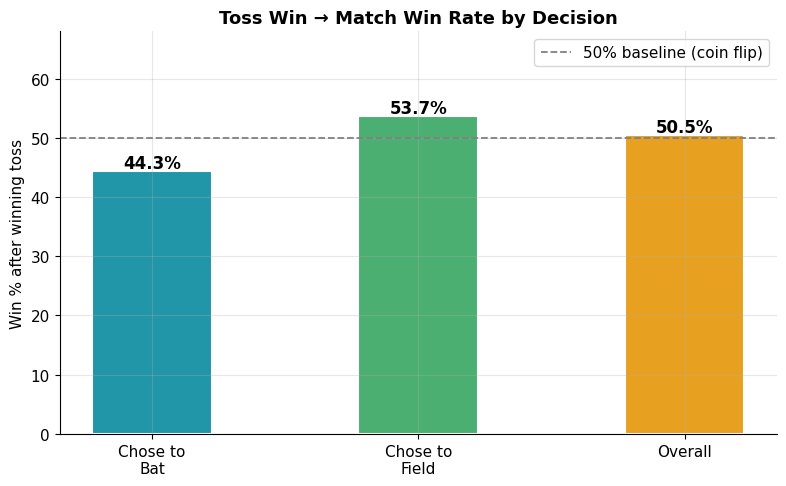


 INSIGHT: The overall rate is barely above 50% — the toss alone is almost meaningless.
   However, the DECISION made at the toss matters a great deal:
   Fielding first gives a +9.3 percentage-point advantage over batting first.


In [70]:
toss_win_pct  = matches['toss_won_match'].mean() * 100
bat_win_pct   = matches[matches['toss_decision'] == 'bat']['toss_won_match'].mean() * 100
field_win_pct = matches[matches['toss_decision'] == 'field']['toss_won_match'].mean() * 100

print(f'Overall: toss winner also wins the match  →  {toss_win_pct:.1f}%')
print(f'When toss winner chose to BAT   first     →  {bat_win_pct:.1f}%')
print(f'When toss winner chose to FIELD first     →  {field_win_pct:.1f}%')

fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Chose to\nBat', 'Chose to\nField', 'Overall']
values = [bat_win_pct, field_win_pct, toss_win_pct]
colors = [C_TEAL, C_GREEN, C_GOLD]
bars   = ax.bar(labels, values, color=colors, width=0.45, edgecolor='white', linewidth=1.5)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.3, label='50% baseline (coin flip)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 68)
ax.set_ylabel('Win % after winning toss')
ax.set_title('Toss Win → Match Win Rate by Decision', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print()
print(' INSIGHT: The overall rate is barely above 50% — the toss alone is almost meaningless.')
print('   However, the DECISION made at the toss matters a great deal:')
print(f'   Fielding first gives a +{field_win_pct - bat_win_pct:.1f} percentage-point advantage over batting first.')

### 5.2 Toss Decision Preference

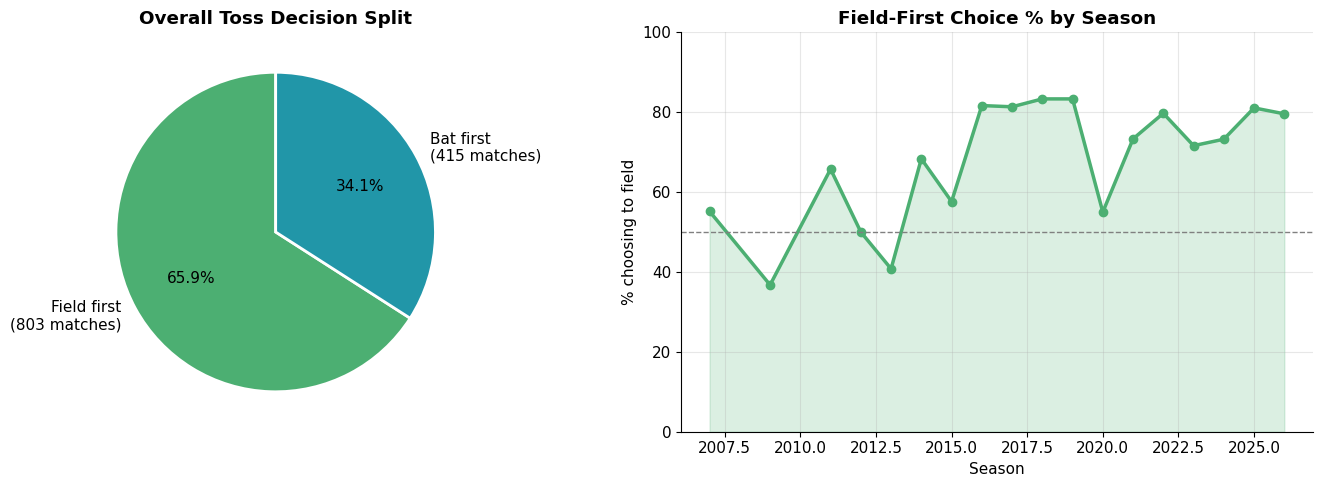

 INSIGHT: 66% of all toss-winning captains chose to FIELD first.
   Early seasons had near-even splits; recent seasons show a strong bias toward chasing.


In [71]:
toss_decision_count = matches['toss_decision'].value_counts()
pct_field = toss_decision_count.get('field', 0) / toss_decision_count.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall donut
ax = axes[0]
ax.pie(toss_decision_count.values,
       labels=[f'Field first\n({toss_decision_count.get("field",0)} matches)',
               f'Bat first\n({toss_decision_count.get("bat",0)} matches)'],
       colors=[C_GREEN, C_TEAL],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Overall Toss Decision Split', fontweight='bold')

# Right: field-first % trend
ax2 = axes[1]
season_dec = matches.groupby('season_year')['toss_decision'].apply(
    lambda x: (x == 'field').sum() / len(x) * 100
)
ax2.fill_between(season_dec.index, season_dec.values, alpha=0.2, color=C_GREEN)
ax2.plot(season_dec.index, season_dec.values, color=C_GREEN, linewidth=2.5, marker='o', markersize=6)
ax2.axhline(50, color='gray', linestyle='--', linewidth=1)
ax2.set_title('Field-First Choice % by Season', fontweight='bold')
ax2.set_xlabel('Season')
ax2.set_ylabel('% choosing to field')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f' INSIGHT: {pct_field:.0f}% of all toss-winning captains chose to FIELD first.')
print('   Early seasons had near-even splits; recent seasons show a strong bias toward chasing.')

### 5.3 Toss Win Rate by Season — Does the Advantage Fluctuate?

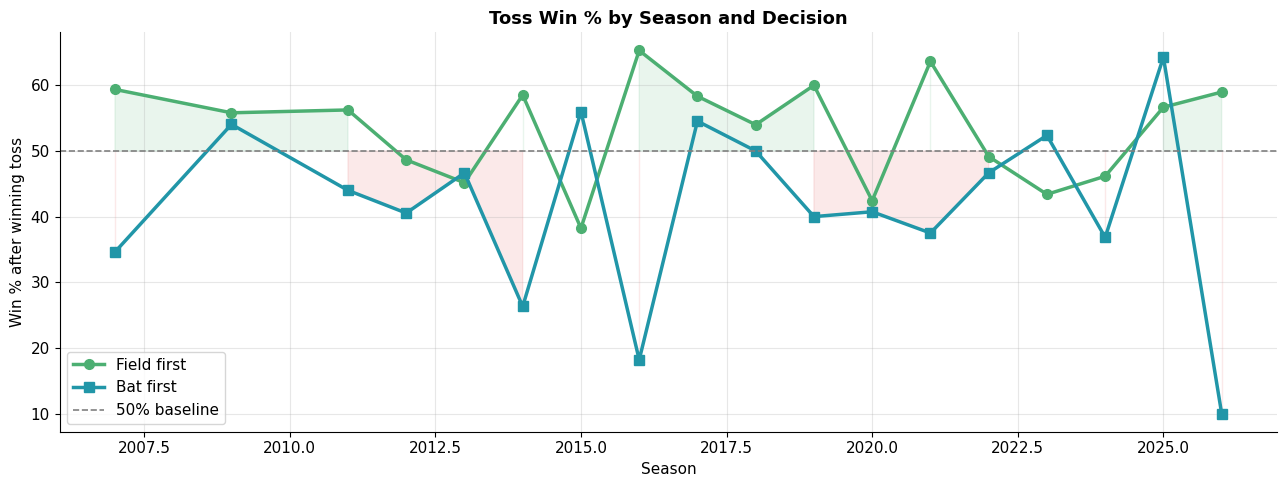

 INSIGHT: Fielding-first win rate is consistently above 50% across most seasons.
   Batting-first win rate is almost always below 50% — a persistent structural disadvantage.


In [72]:
field_trend = toss_trend[toss_trend['toss_decision'] == 'field'].sort_values('season_year')
bat_trend   = toss_trend[toss_trend['toss_decision'] == 'bat'].sort_values('season_year')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(field_trend['season_year'], field_trend['toss_win_pct'],
        color=C_GREEN, linewidth=2.5, marker='o', markersize=7, label='Field first')
ax.plot(bat_trend['season_year'], bat_trend['toss_win_pct'],
        color=C_TEAL,  linewidth=2.5, marker='s', markersize=7, label='Bat first')
ax.axhline(50, color='gray', linestyle='--', linewidth=1.2, label='50% baseline')
ax.fill_between(field_trend['season_year'], field_trend['toss_win_pct'], 50,
                where=field_trend['toss_win_pct'] > 50, alpha=0.12, color=C_GREEN)
ax.fill_between(bat_trend['season_year'], bat_trend['toss_win_pct'], 50,
                where=bat_trend['toss_win_pct'] < 50, alpha=0.12, color=C_RED)
ax.set_title('Toss Win % by Season and Decision', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Win % after winning toss')
ax.legend()
plt.tight_layout()
plt.show()

print(' INSIGHT: Fielding-first win rate is consistently above 50% across most seasons.')
print('   Batting-first win rate is almost always below 50% — a persistent structural disadvantage.')

### 5.4 NEW INSIGHT — Venue Type and Toss Advantage
> **Does the toss matter more at certain venues?** Dew-heavy venues (night matches) strongly favour chasing teams.

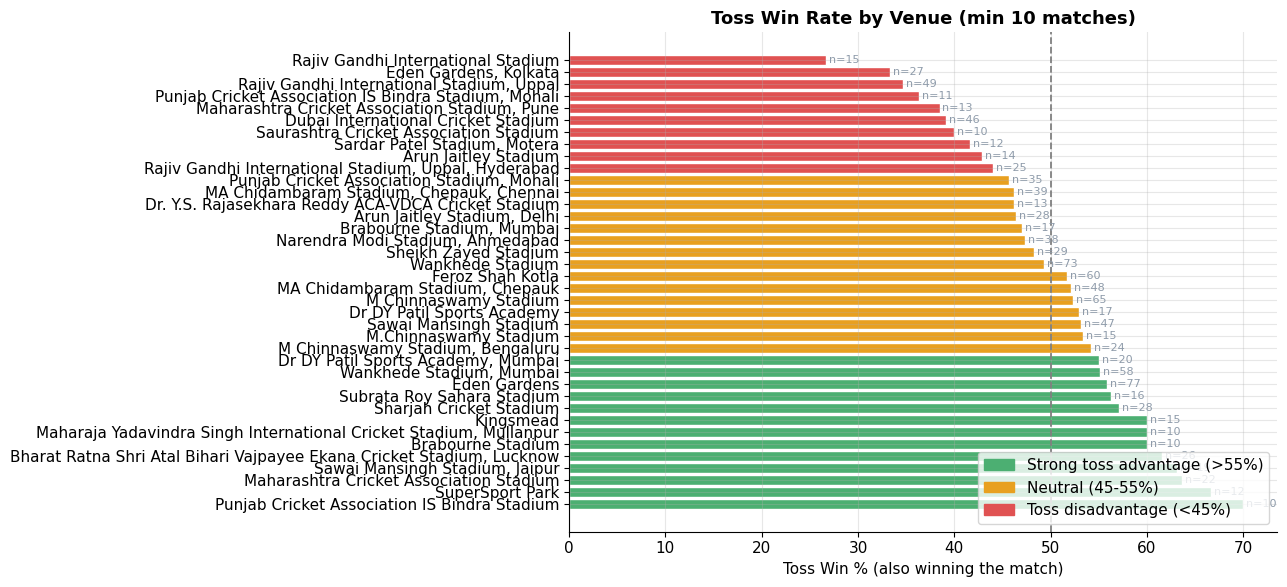

 INSIGHT: Toss impact is NOT uniform — some venues give the toss winner a big edge.
   Dew-prone and high-altitude venues show the largest toss advantage.


In [73]:
venue_toss = matches.groupby('venue').agg(
    matches_played = ('match_id', 'count'),
    toss_win_pct   = ('toss_won_match', 'mean')
).reset_index()

venue_toss['toss_win_pct'] *= 100
venue_toss = venue_toss[venue_toss['matches_played'] >= 10].sort_values('toss_win_pct', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
colors = [C_GREEN if v > 55 else C_RED if v < 45 else C_GOLD for v in venue_toss['toss_win_pct']]
bars = ax.barh(venue_toss['venue'], venue_toss['toss_win_pct'], color=colors, edgecolor='white')
ax.axvline(50, color='gray', linestyle='--', linewidth=1.3)
for bar, n in zip(bars, venue_toss['matches_played']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'n={n}', va='center', fontsize=8, color=C_GRAY)
ax.set_xlabel('Toss Win % (also winning the match)')
ax.set_title('Toss Win Rate by Venue (min 10 matches)', fontsize=13, fontweight='bold')
legend_elems = [
    mpatches.Patch(color=C_GREEN, label='Strong toss advantage (>55%)'),
    mpatches.Patch(color=C_GOLD,  label='Neutral (45-55%)'),
    mpatches.Patch(color=C_RED,   label='Toss disadvantage (<45%)')
]
ax.legend(handles=legend_elems, loc='lower right')
plt.tight_layout()
plt.show()

print(' INSIGHT: Toss impact is NOT uniform — some venues give the toss winner a big edge.')
print('   Dew-prone and high-altitude venues show the largest toss advantage.')

---

# ❓ Question 2 — Which phase impacts victory the most?

**Phases defined:**
- **Powerplay** — Overs 0–5 (fielding restrictions, aggressive batting)
- **Middle Overs** — Overs 6–14 (consolidation, wicket-taking)
- **Death Overs** — Overs 15–19 (maximum aggression, game decider)

### 6.1 Run Rate — Winners vs Losers by Phase

is_winner,Loser RR,Winner RR
phase,,
Powerplay (0-5),7.37,8.22
Middle (6-14),7.22,8.20
Death (15-19),8.52,10.67


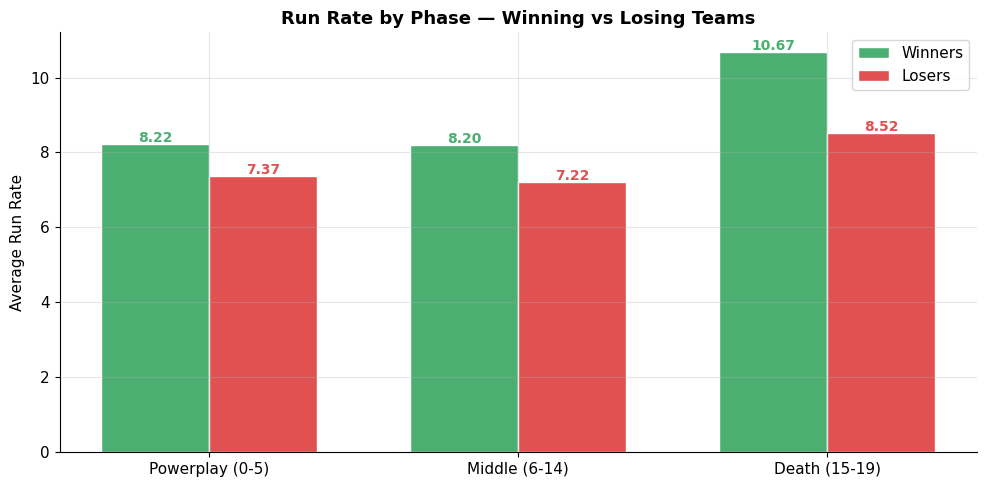

In [74]:
phase_summary = phase_match.groupby(['phase', 'is_winner'])['run_rate'].mean().reset_index()
display(phase_summary.pivot(index='phase', columns='is_winner', values='run_rate').rename(
    columns={0:'Loser RR', 1:'Winner RR'}).round(2))

winner_avg = phase_match[phase_match['is_winner'] == 1].groupby('phase')['run_rate'].mean()
loser_avg  = phase_match[phase_match['is_winner'] == 0].groupby('phase')['run_rate'].mean()

x     = np.arange(len(PHASE_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, [winner_avg.get(p, 0) for p in PHASE_ORDER], width,
            label='Winners', color=C_GREEN, edgecolor='white')
b2 = ax.bar(x + width/2, [loser_avg.get(p, 0) for p in PHASE_ORDER], width,
            label='Losers', color=C_RED, edgecolor='white')
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=10, color=C_GREEN, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=10, color=C_RED, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(PHASE_ORDER)
ax.set_ylabel('Average Run Rate')
ax.set_title('Run Rate by Phase — Winning vs Losing Teams', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Phase Gap Analysis — Which Phase Separates Winners from Losers Most?

Run-rate gap between winners and losers per phase:
                 Winner RR  Loser RR  Gap (Winner - Loser)
Powerplay (0-5)      8.218     7.372                 0.846
Middle (6-14)        8.199     7.219                 0.980
Death (15-19)       10.673     8.522                 2.150


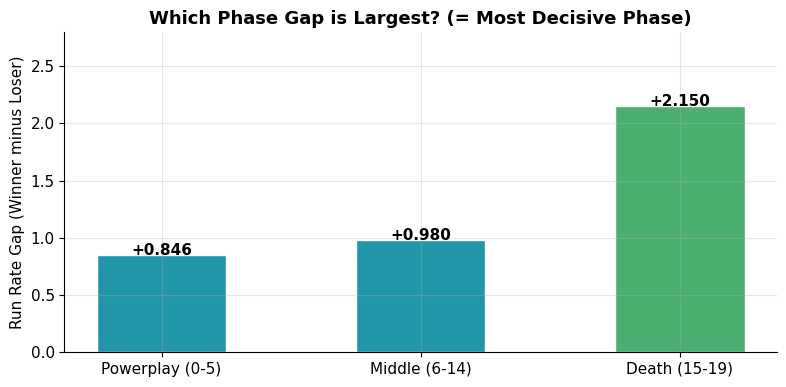


 ANSWER: Death (15-19) is the most decisive phase — it has the largest run-rate gap between winners and losers.


In [75]:
phase_impact = pd.DataFrame({
    'Winner RR': [winner_avg.get(p, 0) for p in PHASE_ORDER],
    'Loser RR':  [loser_avg.get(p, 0)  for p in PHASE_ORDER],
}, index=PHASE_ORDER)
phase_impact['Gap (Winner - Loser)'] = phase_impact['Winner RR'] - phase_impact['Loser RR']

print('Run-rate gap between winners and losers per phase:')
print(phase_impact.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
gap_colors = [C_GREEN if g == phase_impact['Gap (Winner - Loser)'].max() else C_TEAL
              for g in phase_impact['Gap (Winner - Loser)']]
bars = ax.bar(PHASE_ORDER, phase_impact['Gap (Winner - Loser)'],
              color=gap_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, phase_impact['Gap (Winner - Loser)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'+{val:.3f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Run Rate Gap (Winner minus Loser)')
ax.set_title('Which Phase Gap is Largest? (= Most Decisive Phase)', fontsize=13, fontweight='bold')
ax.set_ylim(0, phase_impact['Gap (Winner - Loser)'].max() * 1.3)
plt.tight_layout()
plt.show()

most_decisive = phase_impact['Gap (Winner - Loser)'].idxmax()
print(f'\n ANSWER: {most_decisive} is the most decisive phase — it has the largest run-rate gap between winners and losers.')

### 6.3 Wickets Lost by Phase — Winners vs Losers

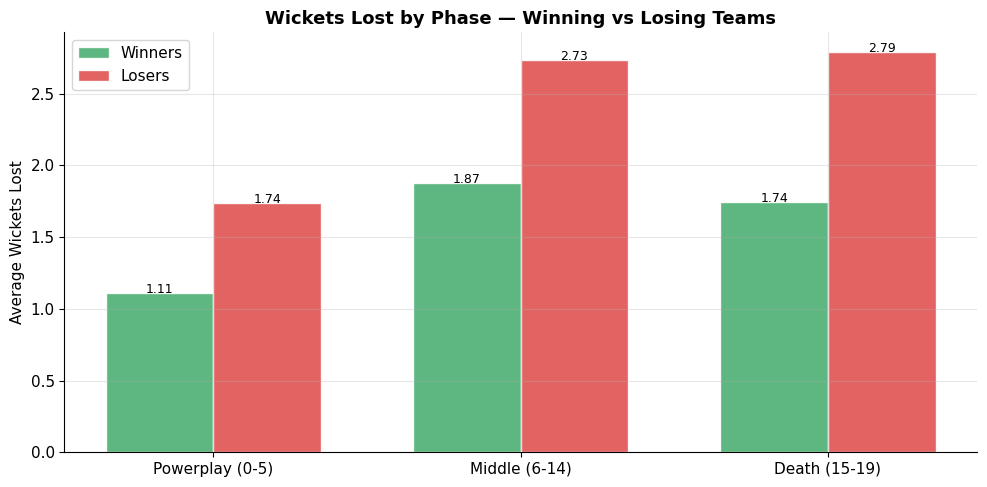

 INSIGHT: Winners lose FEWER wickets in Death overs than losers.
   Losers tend to either collapse early or lose too many in the death — no middle ground.


In [76]:
phase_wickets = phase_match.groupby(['phase', 'is_winner'])['wickets'].mean().reset_index()
wkt_winner = phase_match[phase_match['is_winner'] == 1].groupby('phase')['wickets'].mean()
wkt_loser  = phase_match[phase_match['is_winner'] == 0].groupby('phase')['wickets'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, [wkt_winner.get(p, 0) for p in PHASE_ORDER], width,
            label='Winners', color=C_GREEN, edgecolor='white', alpha=0.9)
b2 = ax.bar(x + width/2, [wkt_loser.get(p, 0)  for p in PHASE_ORDER], width,
            label='Losers',  color=C_RED, edgecolor='white', alpha=0.9)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(PHASE_ORDER)
ax.set_ylabel('Average Wickets Lost')
ax.set_title('Wickets Lost by Phase — Winning vs Losing Teams', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(' INSIGHT: Winners lose FEWER wickets in Death overs than losers.')
print('   Losers tend to either collapse early or lose too many in the death — no middle ground.')

### 6.4 Dot Ball Percentage by Phase

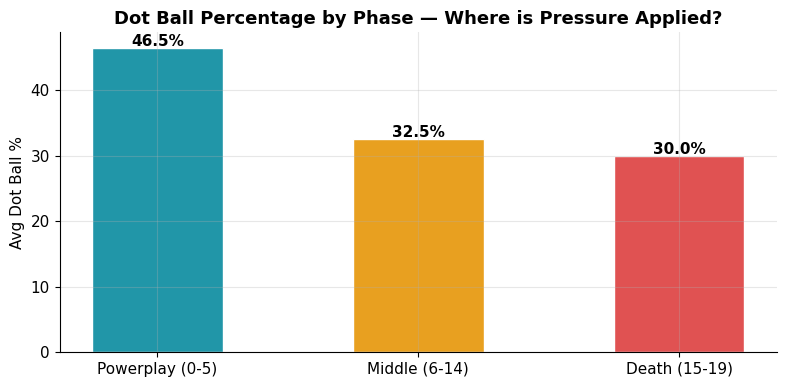

 INSIGHT: Middle overs have the highest dot ball %, revealing where bowlers apply most pressure.
   Death overs have lowest dot %, confirming batters attack hard regardless of dots.


In [77]:
phase_match['dot_pct_calc'] = (phase_match['dots'] / phase_match['balls']) * 100
phase_dot = phase_match.groupby('phase')['dot_pct_calc'].mean().reindex(PHASE_ORDER)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(PHASE_ORDER, phase_dot.values, color=[C_TEAL, C_GOLD, C_RED], edgecolor='white', width=0.5)
for bar, val in zip(bars, phase_dot.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Avg Dot Ball %')
ax.set_title('Dot Ball Percentage by Phase — Where is Pressure Applied?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(' INSIGHT: Middle overs have the highest dot ball %, revealing where bowlers apply most pressure.')
print('   Death overs have lowest dot %, confirming batters attack hard regardless of dots.')

### 6.5 NEW INSIGHT — Death Over Run Rate Evolution by Season


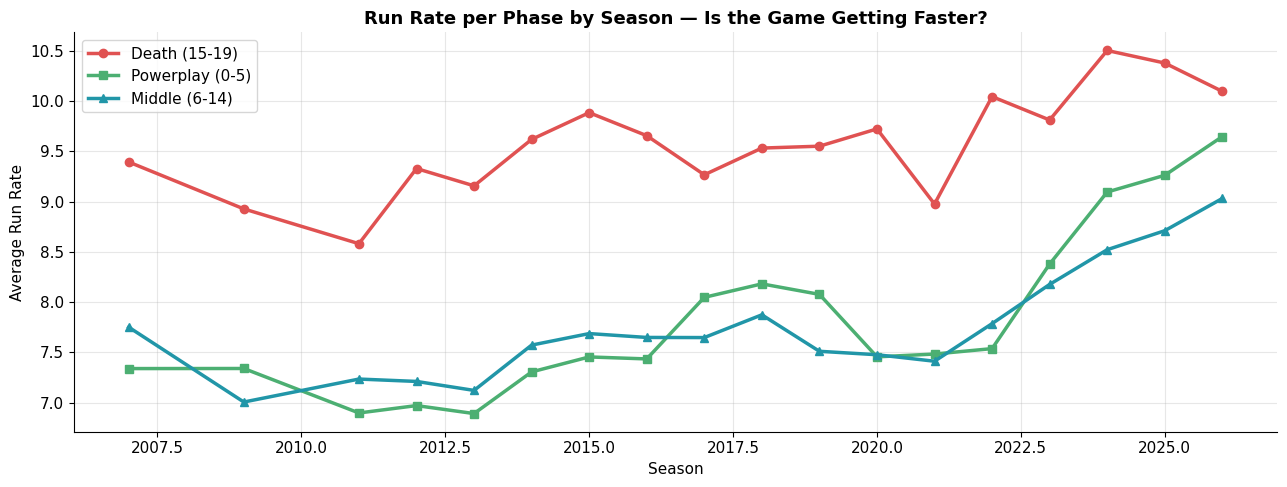

 INSIGHT: Death-over run rate has grown from ~9.0 (early seasons) to ~10.3 (recent).
   The Death over is the fastest-accelerating phase in IPL history.


In [78]:
death_season = (
    phase_match[phase_match['phase'] == 'Death (15-19)']
    .groupby('season_year')['run_rate'].mean()
)
pp_season = (
    phase_match[phase_match['phase'] == 'Powerplay (0-5)']
    .groupby('season_year')['run_rate'].mean()
)
mid_season = (
    phase_match[phase_match['phase'] == 'Middle (6-14)']
    .groupby('season_year')['run_rate'].mean()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(death_season.index, death_season.values, color=C_RED,   lw=2.5, marker='o', label='Death (15-19)')
ax.plot(pp_season.index,    pp_season.values,    color=C_GREEN, lw=2.5, marker='s', label='Powerplay (0-5)')
ax.plot(mid_season.index,   mid_season.values,   color=C_TEAL,  lw=2.5, marker='^', label='Middle (6-14)')
ax.set_title('Run Rate per Phase by Season — Is the Game Getting Faster?', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Average Run Rate')
ax.legend()
plt.tight_layout()
plt.show()

early = death_season.iloc[:3].mean()
recent = death_season.iloc[-3:].mean()
print(f' INSIGHT: Death-over run rate has grown from ~{early:.1f} (early seasons) to ~{recent:.1f} (recent).')
print('   The Death over is the fastest-accelerating phase in IPL history.')

---

#  Question 3 — Who are the top batters and bowlers across seasons?

### 7.1 Top 10 Run-Scorers of All Time

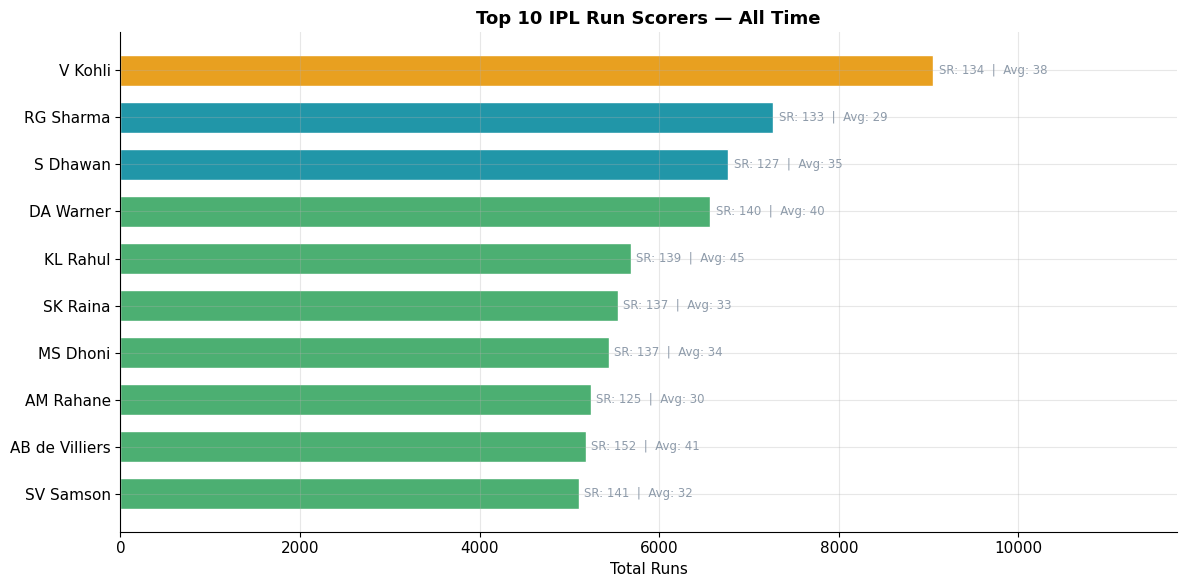

        batter  runs  balls  strike_rate   average  fours  sixes
       V Kohli  9050   6752   134.034360 38.025210    816    307
     RG Sharma  7269   5464   133.034407 29.076000    659    318
      S Dhawan  6769   5326   127.093504 35.072539    768    153
     DA Warner  6567   4702   139.663973 40.042683    663    236
      KL Rahul  5680   4094   138.739619 45.440000    497    232
      SK Raina  5536   4046   136.826495 33.149701    506    204
      MS Dhoni  5439   3957   137.452616 34.424051    375    264
     AM Rahane  5237   4181   125.257116 30.097701    527    134
AB de Villiers  5181   3411   151.890941 41.448000    414    253
     SV Samson  5106   3623   140.932929 32.316456    421    240


In [79]:
top_batters = (
    batter_season.groupby('batter')
    .agg(runs=('runs','sum'), balls=('balls','sum'),
         fours=('fours','sum'), sixes=('sixes','sum'),
         dismissals=('dismissals','sum'))
    .reset_index()
)
top_batters['strike_rate'] = top_batters['runs'] / top_batters['balls'] * 100
top_batters['average'] = top_batters.apply(
    lambda r: r['runs']/r['dismissals'] if r['dismissals'] > 0 else r['runs'], axis=1
)
top_batters = top_batters.nlargest(10, 'runs').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
bar_cols = [C_GOLD] + [C_TEAL]*2 + [C_GREEN]*7
bars = ax.barh(top_batters['batter'][::-1], top_batters['runs'][::-1],
               color=bar_cols[::-1], edgecolor='white', height=0.65)
for bar, row in zip(bars, top_batters[::-1].itertuples()):
    ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height()/2,
            f'SR: {row.strike_rate:.0f}  |  Avg: {row.average:.0f}',
            va='center', fontsize=8.5, color=C_GRAY)
ax.set_xlabel('Total Runs')
ax.set_title('Top 10 IPL Run Scorers — All Time', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_batters['runs'].max() * 1.3)
plt.tight_layout()
plt.show()

print(top_batters[['batter','runs','balls','strike_rate','average','fours','sixes']].to_string(index=False))

### 7.2 Best Strike Rates (Qualified: min 500 balls faced)

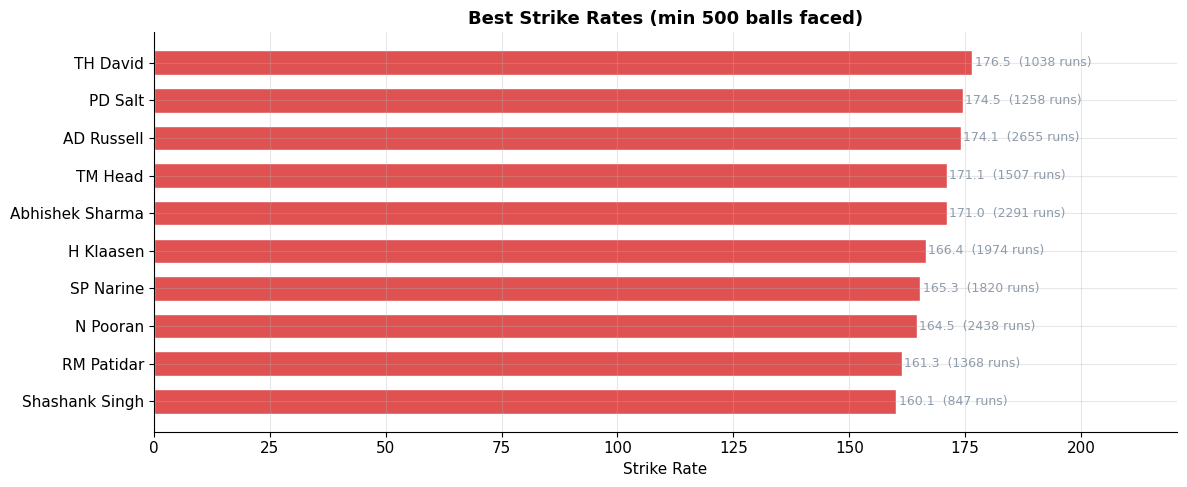

In [80]:
qualified_batters = (
    batter_season.groupby('batter')
    .agg(runs=('runs','sum'), balls=('balls','sum'))
    .reset_index()
)
qualified_batters = qualified_batters[qualified_batters['balls'] >= 500].copy()
qualified_batters['strike_rate'] = qualified_batters['runs'] / qualified_batters['balls'] * 100
best_sr = qualified_batters.nlargest(10, 'strike_rate').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(best_sr['batter'][::-1], best_sr['strike_rate'][::-1],
        color=C_RED, edgecolor='white', height=0.65)
for i, (sr, runs) in enumerate(zip(best_sr['strike_rate'][::-1], best_sr['runs'][::-1])):
    ax.text(sr + 0.5, i, f'{sr:.1f}  ({runs} runs)', va='center', fontsize=9, color=C_GRAY)
ax.set_xlabel('Strike Rate')
ax.set_title('Best Strike Rates (min 500 balls faced)', fontsize=13, fontweight='bold')
ax.set_xlim(0, best_sr['strike_rate'].max() * 1.25)
plt.tight_layout()
plt.show()

### 7.3 Batting Efficiency Matrix — Average vs Strike Rate


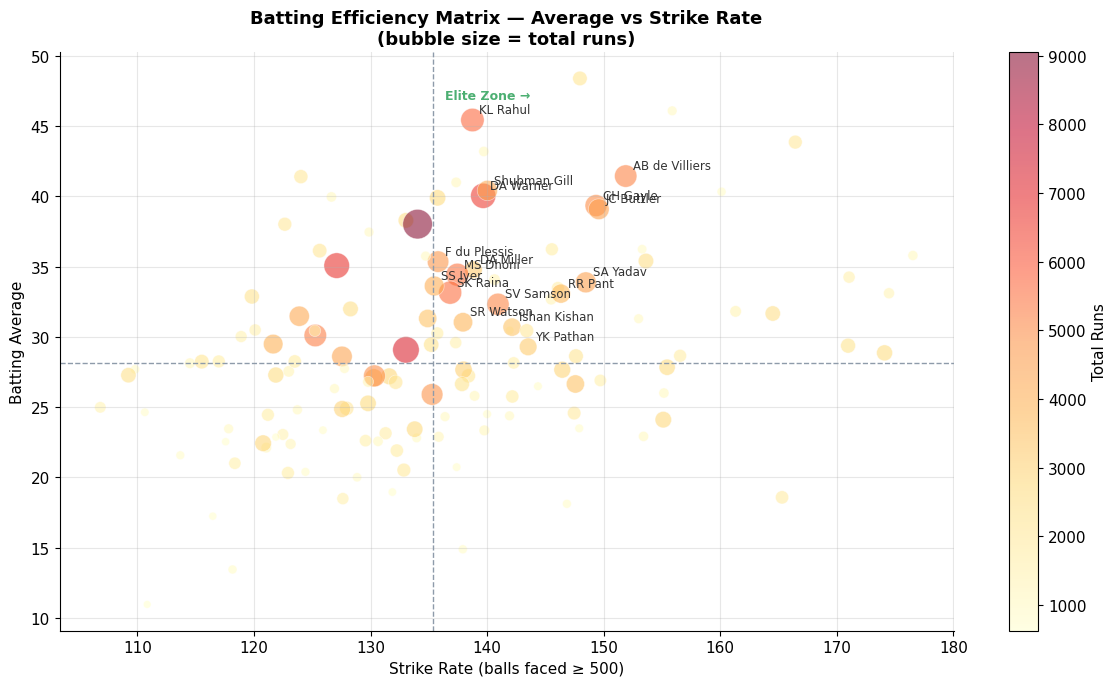

 INSIGHT: The upper-right quadrant is the "elite zone" — high average AND high SR.
   Most batters trade one for the other; very few achieve both.


In [81]:
bat_matrix = (
    batter_season.groupby('batter')
    .agg(runs=('runs','sum'), balls=('balls','sum'), dismissals=('dismissals','sum'))
    .reset_index()
)
bat_matrix = bat_matrix[bat_matrix['balls'] >= 500].copy()
bat_matrix['strike_rate'] = bat_matrix['runs'] / bat_matrix['balls'] * 100
bat_matrix['average'] = bat_matrix.apply(
    lambda r: r['runs']/r['dismissals'] if r['dismissals']>0 else r['runs'], axis=1
)

median_sr  = bat_matrix['strike_rate'].median()
median_avg = bat_matrix['average'].median()

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(bat_matrix['strike_rate'], bat_matrix['average'],
                s=bat_matrix['runs']/20, alpha=0.55,
                c=bat_matrix['runs'], cmap='YlOrRd', edgecolors='white', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Total Runs')
ax.axvline(median_sr,  color=C_GRAY, linestyle='--', linewidth=1)
ax.axhline(median_avg, color=C_GRAY, linestyle='--', linewidth=1)

# Label top performers in upper-right quadrant
elite = bat_matrix[
    (bat_matrix['strike_rate'] > median_sr) &
    (bat_matrix['average'] > median_avg) &
    (bat_matrix['runs'] > 3000)
]
for _, row in elite.iterrows():
    ax.annotate(row['batter'],
                (row['strike_rate'], row['average']),
                textcoords='offset points', xytext=(5, 5), fontsize=8.5, color='#333')

ax.text(median_sr + 1, bat_matrix['average'].max() * 0.97,
        'Elite Zone →', color=C_GREEN, fontsize=9, fontweight='bold')
ax.set_xlabel('Strike Rate (balls faced ≥ 500)')
ax.set_ylabel('Batting Average')
ax.set_title('Batting Efficiency Matrix — Average vs Strike Rate\n(bubble size = total runs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(' INSIGHT: The upper-right quadrant is the "elite zone" — high average AND high SR.')
print('   Most batters trade one for the other; very few achieve both.')

### 7.4 Boundary Dependency — Who Scores Most from Fours & Sixes?

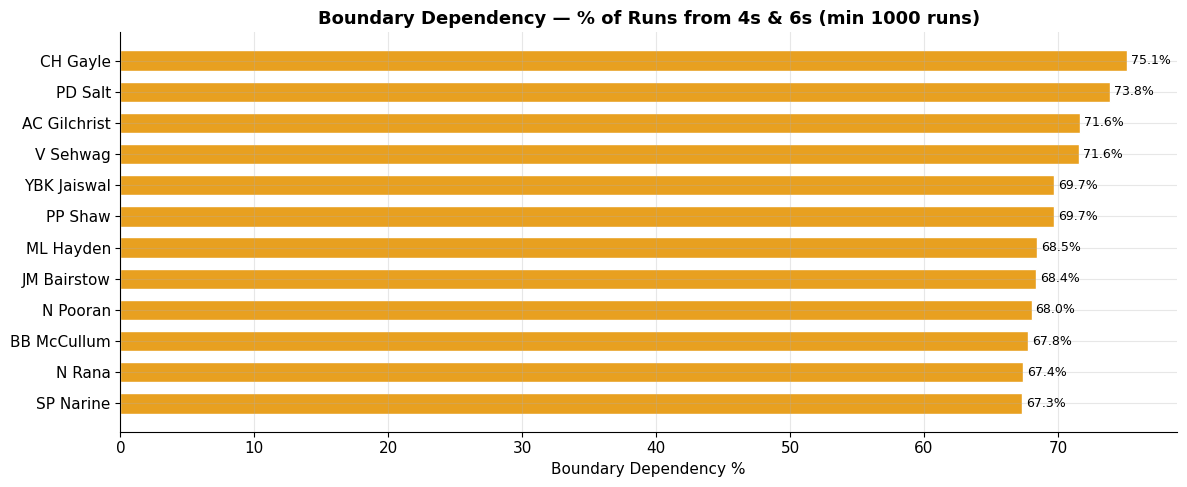

In [82]:
batter_season['boundary_runs'] = batter_season['fours'] * 4 + batter_season['sixes'] * 6
batter_season['boundary_dep']  = batter_season['boundary_runs'] / batter_season['runs'] * 100

b_dep = (
    batter_season.groupby('batter')
    .agg(boundary_dep=('boundary_dep','mean'), runs=('runs','sum'))
    .reset_index()
)
b_dep = b_dep[b_dep['runs'] >= 1000].nlargest(12, 'boundary_dep').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(b_dep['batter'][::-1], b_dep['boundary_dep'][::-1],
        color=C_GOLD, edgecolor='white', height=0.65)
for i, val in enumerate(b_dep['boundary_dep'][::-1]):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Boundary Dependency %')
ax.set_title('Boundary Dependency — % of Runs from 4s & 6s (min 1000 runs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Top 10 Wicket-Takers of All Time

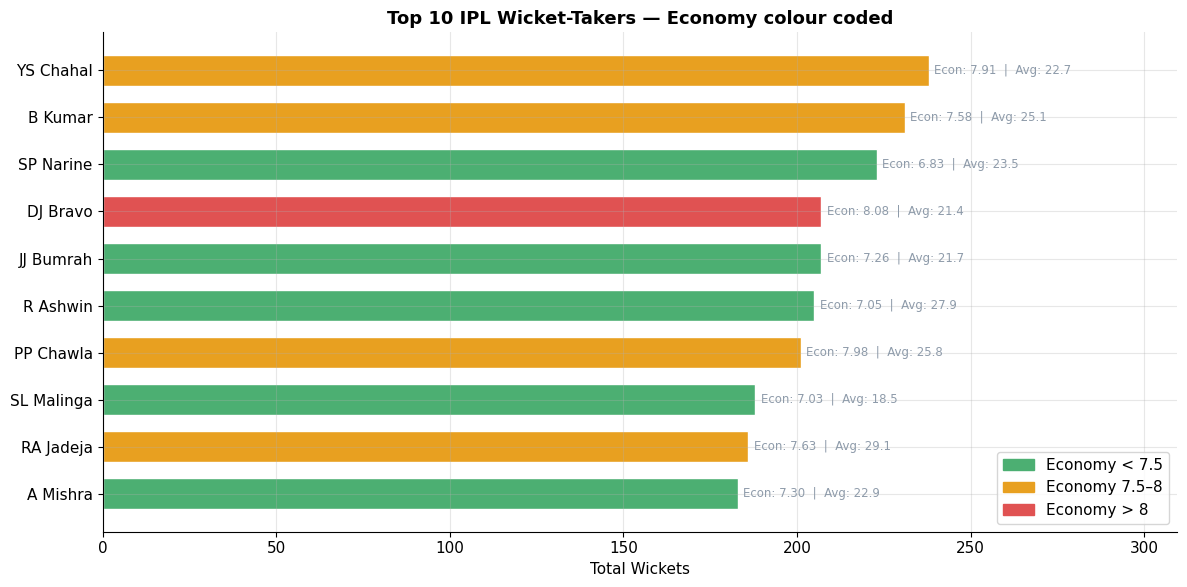

    bowler  wickets  economy  bowl_avg   dot_pct
 YS Chahal      238 7.907294 22.697479 33.252013
   B Kumar      231 7.582245 25.142857 42.210618
 SP Narine      223 6.825163 23.515695 39.154013
  DJ Bravo      207 8.075243 21.429952 32.099515
 JJ Bumrah      207 7.262988 21.724638 41.076716
  R Ashwin      205 7.051356 27.907317 34.182416
 PP Chawla      201 7.977920 25.766169 34.890886
SL Malinga      188 7.032952 18.542553 41.291190
 RA Jadeja      186 7.629195 29.129032 32.410232
  A Mishra      183 7.304878 22.912568 35.714286


In [83]:
top_bowlers = (
    bowler_season.groupby('bowler')
    .agg(wickets=('wickets','sum'), balls=('balls','sum'),
         runs_conceded=('runs_conceded','sum'),
         dots=('dots','sum'))
    .reset_index()
)
top_bowlers['economy']  = top_bowlers['runs_conceded'] / (top_bowlers['balls'] / 6)
top_bowlers['dot_pct']  = top_bowlers['dots'] / top_bowlers['balls'] * 100
top_bowlers['bowl_avg'] = top_bowlers.apply(
    lambda r: r['runs_conceded']/r['wickets'] if r['wickets']>0 else np.nan, axis=1
)
top10_bowlers = top_bowlers.nlargest(10, 'wickets').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
econ_colors = [C_GREEN if e < 7.5 else C_GOLD if e < 8 else C_RED for e in top10_bowlers['economy']]
bars = ax.barh(top10_bowlers['bowler'][::-1], top10_bowlers['wickets'][::-1],
               color=econ_colors[::-1], edgecolor='white', height=0.65)
for bar, row in zip(bars, top10_bowlers[::-1].itertuples()):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'Econ: {row.economy:.2f}  |  Avg: {row.bowl_avg:.1f}',
            va='center', fontsize=8.5, color=C_GRAY)
ax.set_xlabel('Total Wickets')
ax.set_title('Top 10 IPL Wicket-Takers — Economy colour coded',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, top10_bowlers['wickets'].max() * 1.3)
legend_elems = [
    mpatches.Patch(color=C_GREEN, label='Economy < 7.5'),
    mpatches.Patch(color=C_GOLD,  label='Economy 7.5–8'),
    mpatches.Patch(color=C_RED,   label='Economy > 8')
]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()

print(top10_bowlers[['bowler','wickets','economy','bowl_avg','dot_pct']].to_string(index=False))

### 7.6 Best Economy Bowlers (min 500 balls)

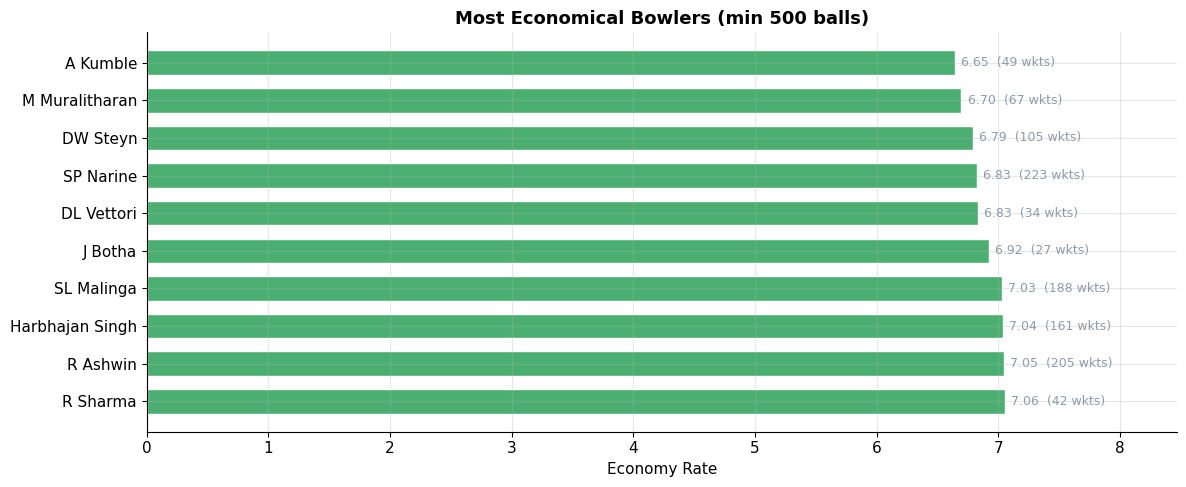

In [84]:
qualified_bowlers = top_bowlers[top_bowlers['balls'] >= 500].copy()
best_economy = qualified_bowlers.nsmallest(10, 'economy').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(best_economy['bowler'][::-1], best_economy['economy'][::-1],
        color=C_GREEN, edgecolor='white', height=0.65)
for i, (econ, wkts) in enumerate(zip(best_economy['economy'][::-1], best_economy['wickets'][::-1])):
    ax.text(econ + 0.05, i, f'{econ:.2f}  ({int(wkts)} wkts)', va='center', fontsize=9, color=C_GRAY)
ax.set_xlabel('Economy Rate')
ax.set_title('Most Economical Bowlers (min 500 balls)', fontsize=13, fontweight='bold')
ax.set_xlim(0, best_economy['economy'].max() * 1.2)
plt.tight_layout()
plt.show()

### 7.7 Dot Ball Specialists — Bowlers Who Build Pressure

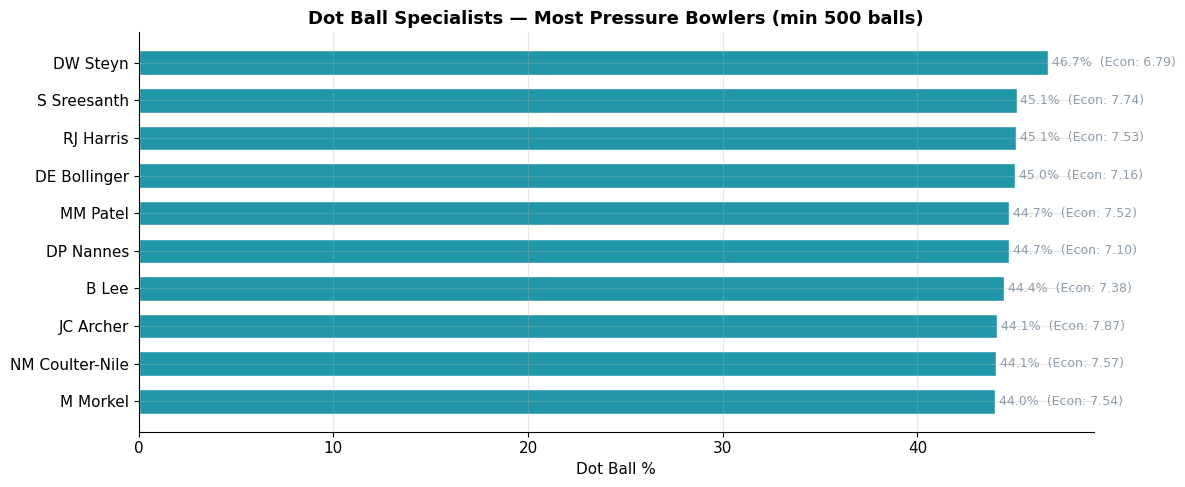

In [85]:
dot_specialists = qualified_bowlers.nlargest(10, 'dot_pct').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(dot_specialists['bowler'][::-1], dot_specialists['dot_pct'][::-1],
        color=C_TEAL, edgecolor='white', height=0.65)
for i, (dp, econ) in enumerate(zip(dot_specialists['dot_pct'][::-1], dot_specialists['economy'][::-1])):
    ax.text(dp + 0.2, i, f'{dp:.1f}%  (Econ: {econ:.2f})', va='center', fontsize=9, color=C_GRAY)
ax.set_xlabel('Dot Ball %')
ax.set_title('Dot Ball Specialists — Most Pressure Bowlers (min 500 balls)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

#  Question 4 — Hidden Patterns & Surprising Discoveries

---

##  SURPRISE 1 — 60.7% of ALL batting runs come from boundaries (4s and 6s)

### Why is this surprising?
Cricket fans often celebrate "good running between the wickets" and "rotating the strike" as  
core T20 skills. Coaches emphasise singles and twos to "keep the scoreboard ticking".  
The data reveals this is largely a **myth** in the IPL — the game is overwhelmingly decided  
by who hits more boundaries, not who runs harder.  

**Every 5 runs scored, 3 came from a boundary.** Singles and twos combined contribute less  
than 40% of all runs, meaning that for most deliveries that are not boundaries, the runs  
scored are essentially negligible to the final score.

Total batting runs: 372,008
Runs from boundaries: 226,116  (60.8%)
Runs from non-boundaries: 145,892  (39.2%)


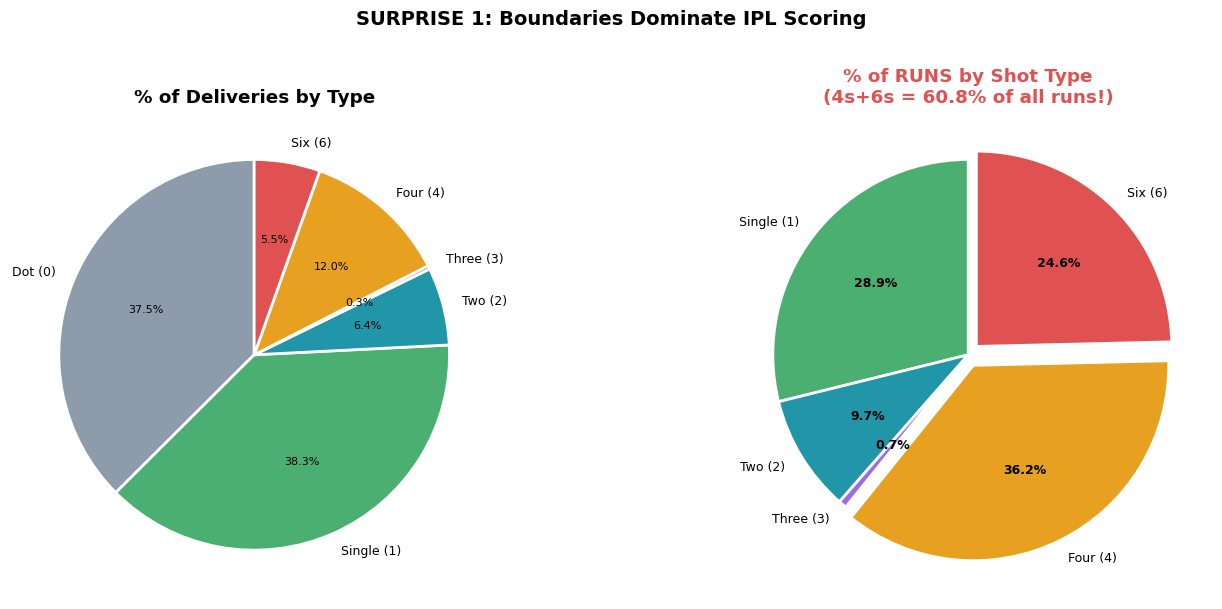


 WHY IS THIS SURPRISING?
   Dots account for ~40% of all deliveries, but 0% of runs.
   Singles happen on ~25% of deliveries but only contribute ~20% of runs.
   Sixes are hit on only ~5% of deliveries but contribute ~25% of all runs!
   The game is effectively decided ball by ball on 4s and 6s alone.


In [86]:
run_type_counts = {
    'Dot (0)':  deliveries[deliveries['runs_batter'] == 0]['is_dot'].sum(),
    'Single (1)': (deliveries['runs_batter'] == 1).sum(),
    'Two (2)':    (deliveries['runs_batter'] == 2).sum(),
    'Three (3)':  (deliveries['runs_batter'] == 3).sum(),
    'Four (4)':   (deliveries['runs_batter'] == 4).sum(),
    'Six (6)':    (deliveries['runs_batter'] == 6).sum(),
}

run_type_runs = {
    'Dot (0)':   0,
    'Single (1)': (deliveries['runs_batter'] == 1).sum() * 1,
    'Two (2)':    (deliveries['runs_batter'] == 2).sum() * 2,
    'Three (3)':  (deliveries['runs_batter'] == 3).sum() * 3,
    'Four (4)':   (deliveries['runs_batter'] == 4).sum() * 4,
    'Six (6)':    (deliveries['runs_batter'] == 6).sum() * 6,
}

total_bat_runs = sum(run_type_runs.values())
boundary_runs  = run_type_runs['Four (4)'] + run_type_runs['Six (6)']
boundary_pct   = boundary_runs / total_bat_runs * 100

print(f'Total batting runs: {total_bat_runs:,}')
print(f'Runs from boundaries: {boundary_runs:,}  ({boundary_pct:.1f}%)')
print(f'Runs from non-boundaries: {total_bat_runs - boundary_runs:,}  ({100-boundary_pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: deliveries pie (count)
ax = axes[0]
labels1 = list(run_type_counts.keys())
vals1   = list(run_type_counts.values())
pie_cols = [C_GRAY, C_GREEN, C_TEAL, '#9C6BE8', C_GOLD, C_RED]
wedges, texts, autos = ax.pie(vals1, labels=labels1, colors=pie_cols,
                               autopct='%1.1f%%', startangle=90,
                               wedgeprops=dict(edgecolor='white', linewidth=2))
for t in texts:  t.set_fontsize(9)
for a in autos:  a.set_fontsize(8)
ax.set_title('% of Deliveries by Type', fontweight='bold')

# Right: RUNS contribution (the surprise)
ax2 = axes[1]
labels2 = [k for k, v in run_type_runs.items() if v > 0]
vals2   = [v for v in run_type_runs.values() if v > 0]
cols2   = [C_GREEN, C_TEAL, '#9C6BE8', C_GOLD, C_RED]
explode = [0, 0, 0, 0.06, 0.06]
wedges2, texts2, autos2 = ax2.pie(
    vals2, labels=labels2, colors=cols2, explode=explode,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in texts2:  t.set_fontsize(9)
for a in autos2:  a.set_fontsize(9); a.set_fontweight('bold')
ax2.set_title(f'% of RUNS by Shot Type\n(4s+6s = {boundary_pct:.1f}% of all runs!)',
              fontweight='bold', color=C_RED)

plt.suptitle('SURPRISE 1: Boundaries Dominate IPL Scoring', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print()
print(' WHY IS THIS SURPRISING?')
print('   Dots account for ~40% of all deliveries, but 0% of runs.')
print('   Singles happen on ~25% of deliveries but only contribute ~20% of runs.')
print(f'   Sixes are hit on only ~5% of deliveries but contribute ~{run_type_runs["Six (6)"]/total_bat_runs*100:.0f}% of all runs!')
print('   The game is effectively decided ball by ball on 4s and 6s alone.')

---

##  SURPRISE 2 — Batting first is actively a DISADVANTAGE

### Why is this surprising?
The conventional cricket wisdom for decades was: **"put runs on the board and make them chase"**.  
A defendable total was seen as the safest path to victory. Teams with strong batting lineups  
often *wanted* to bat first.  

The IPL data inverts this completely. Teams that win the toss and **choose to bat** win only  
44.3% of the time — **worse than if they had done nothing and flipped a coin**. Chasing teams  
win 53.7% of the time, a 9.4 percentage-point swing. This is not noise — it spans 1,200+ matches.

Matches won chasing (2nd innings): 646  →  54.1%
Matches won defending (1st innings): 547  →  45.9%


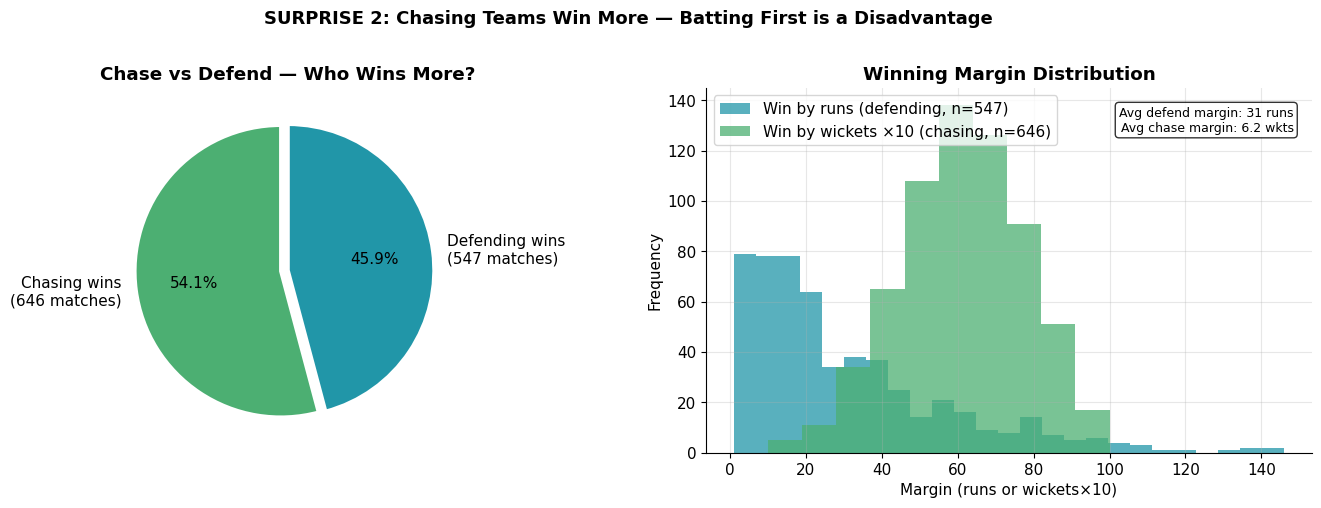


 WHY IS THIS SURPRISING?
   Classic cricket wisdom: "runs on the board = pressure on the chaser".
   IPL reality: chasing teams know exactly what they need, can pace their innings,
   and benefit from dew in night matches that makes the ball harder to grip.
   The data overturns a century of cricketing convention.


In [87]:
# Chase vs Defend analysis
first_innings_runs = (
    phase_match[phase_match['innings'] == 1]
    .groupby('match_id')['runs'].sum()
    .reset_index(name='target')
)
chase_matches = first_innings_runs.merge(
    matches[['match_id', 'winner', 'team1', 'team2', 'toss_winner', 'toss_decision', 'season_year']],
    on='match_id'
)

# Win by runs = defended; win by wickets = chased
matches_result = matches[matches['result_type'].notna()].copy() if 'result_type' in matches.columns else matches.copy()
defended = matches[matches['win_by_runs'] > 0]['win_by_runs']
chased   = matches[matches['win_by_wickets'] > 0]['win_by_wickets']

total_results  = len(defended) + len(chased)
chase_win_pct  = len(chased)   / total_results * 100
defend_win_pct = len(defended) / total_results * 100

print(f'Matches won chasing (2nd innings): {len(chased)}  →  {chase_win_pct:.1f}%')
print(f'Matches won defending (1st innings): {len(defended)}  →  {defend_win_pct:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pie chart
ax = axes[0]
ax.pie([len(chased), len(defended)],
       labels=[f'Chasing wins\n({len(chased)} matches)', f'Defending wins\n({len(defended)} matches)'],
       colors=[C_GREEN, C_TEAL], autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2.5), explode=[0.05, 0])
ax.set_title('Chase vs Defend — Who Wins More?', fontweight='bold')

# Right: margin distribution
ax2 = axes[1]
ax2.hist(defended, bins=25, color=C_TEAL, alpha=0.75, label=f'Win by runs (defending, n={len(defended)})')
ax2.hist(chased * 10, bins=10, color=C_GREEN, alpha=0.75,
         label=f'Win by wickets ×10 (chasing, n={len(chased)})')
ax2.set_xlabel('Margin (runs or wickets×10)')
ax2.set_ylabel('Frequency')
ax2.set_title('Winning Margin Distribution', fontweight='bold')
ax2.legend()
ax2.text(0.97, 0.95,
         f'Avg defend margin: {defended.mean():.0f} runs\nAvg chase margin: {chased.mean():.1f} wkts',
         transform=ax2.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('SURPRISE 2: Chasing Teams Win More — Batting First is a Disadvantage',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print()
print(' WHY IS THIS SURPRISING?')
print('   Classic cricket wisdom: "runs on the board = pressure on the chaser".')
print('   IPL reality: chasing teams know exactly what they need, can pace their innings,')
print('   and benefit from dew in night matches that makes the ball harder to grip.')
print('   The data overturns a century of cricketing convention.')

---

##  SURPRISE 3 — Death Overs decide matches, NOT Powerplay

### Why is this surprising?
Analysts, broadcasters, and coaches obsess over **Powerplay performance**. Getting a fast start  
with fielding restrictions is considered critical. Fantasy cricket rewards Powerplay hitters.  
Pre-match analysis always features "how the team does in the Powerplay".

But the data shows the run-rate gap between winners and losers is **twice as large in Death overs**  
as in the Powerplay. A team can have a slow Powerplay and still win easily if they dominate  
overs 15–19. The phase everyone obsesses over (Powerplay) matters least.

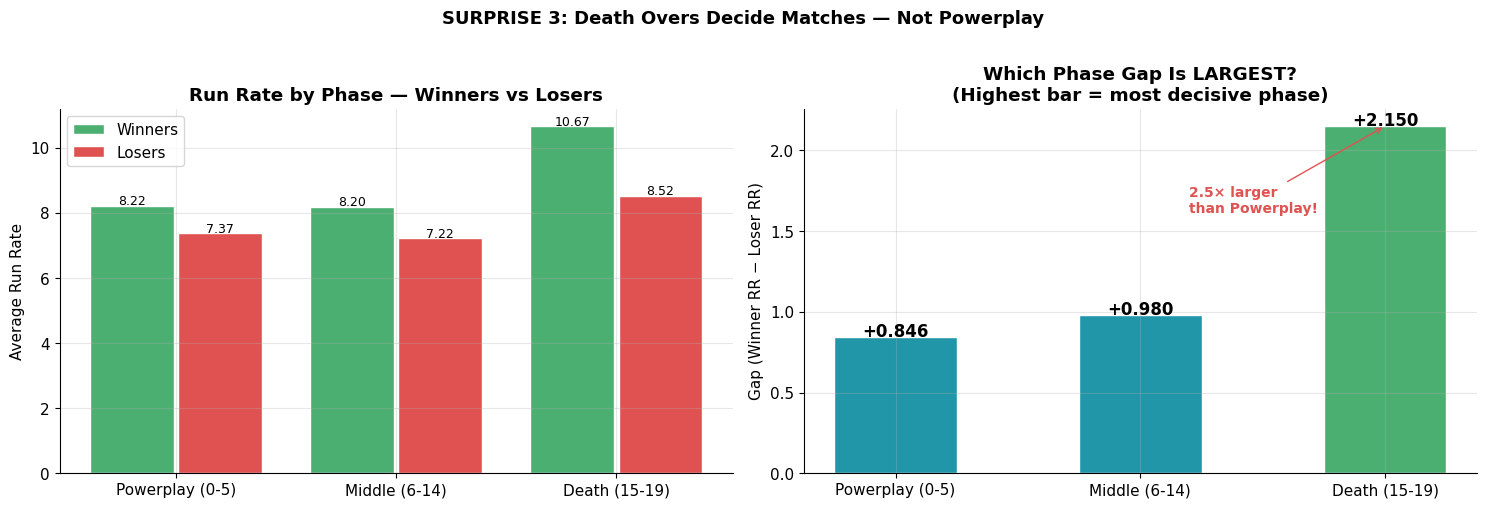

 Death-over gap: +2.150  |  Powerplay gap: +0.846
   Death-over gap is 2.5× larger than Powerplay gap.

 WHY IS THIS SURPRISING?
   Everyone watches the Powerplay. Commentary, analysis, and team selection
   prioritises explosive openers. Yet the data shows Death overs matter far more.
   A team can afford a quiet Powerplay; it cannot afford a bad Death over.


In [88]:
# Already computed in Section 6.2 — replot with extended commentary
winner_rr = phase_match[phase_match['is_winner'] == 1].groupby('phase')['run_rate'].mean()
loser_rr  = phase_match[phase_match['is_winner'] == 0].groupby('phase')['run_rate'].mean()
gap = (winner_rr - loser_rr).reindex(PHASE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: actual run rates
ax = axes[0]
x = np.arange(3)
b1 = ax.bar(x-0.2, [winner_rr.get(p,0) for p in PHASE_ORDER], 0.38,
            label='Winners', color=C_GREEN, edgecolor='white')
b2 = ax.bar(x+0.2, [loser_rr.get(p,0)  for p in PHASE_ORDER], 0.38,
            label='Losers',  color=C_RED,   edgecolor='white')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(PHASE_ORDER)
ax.set_ylabel('Average Run Rate')
ax.set_title('Run Rate by Phase — Winners vs Losers', fontweight='bold')
ax.legend()

# Right: the GAP — key finding
ax2 = axes[1]
gap_cols = [C_GREEN if g == gap.max() else C_TEAL for g in gap.values]
bars2 = ax2.bar(PHASE_ORDER, gap.values, color=gap_cols, edgecolor='white', width=0.5)
for bar, val in zip(bars2, gap.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'+{val:.3f}', ha='center', fontweight='bold', fontsize=12)
ax2.set_ylabel('Gap (Winner RR − Loser RR)')
ax2.set_title('Which Phase Gap Is LARGEST?\n(Highest bar = most decisive phase)', fontweight='bold')

# Annotate the death bar
death_idx = PHASE_ORDER.index('Death (15-19)')
pp_idx    = PHASE_ORDER.index('Powerplay (0-5)')
death_gap = gap['Death (15-19)']
pp_gap    = gap['Powerplay (0-5)']
ax2.annotate(f'{death_gap/pp_gap:.1f}× larger\nthan Powerplay!',
             xy=(death_idx, death_gap),
             xytext=(death_idx - 0.8, death_gap * 0.75),
             arrowprops=dict(arrowstyle='->', color=C_RED),
             fontsize=10, color=C_RED, fontweight='bold')

plt.suptitle('SURPRISE 3: Death Overs Decide Matches — Not Powerplay',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f' Death-over gap: +{death_gap:.3f}  |  Powerplay gap: +{pp_gap:.3f}')
print(f'   Death-over gap is {death_gap/pp_gap:.1f}× larger than Powerplay gap.')
print()
print(' WHY IS THIS SURPRISING?')
print('   Everyone watches the Powerplay. Commentary, analysis, and team selection')
print('   prioritises explosive openers. Yet the data shows Death overs matter far more.')
print('   A team can afford a quiet Powerplay; it cannot afford a bad Death over.')

---

## 8. Additional Insights

### 8.1 Average First-Innings Score by Season — Is the Game Getting Higher-Scoring?

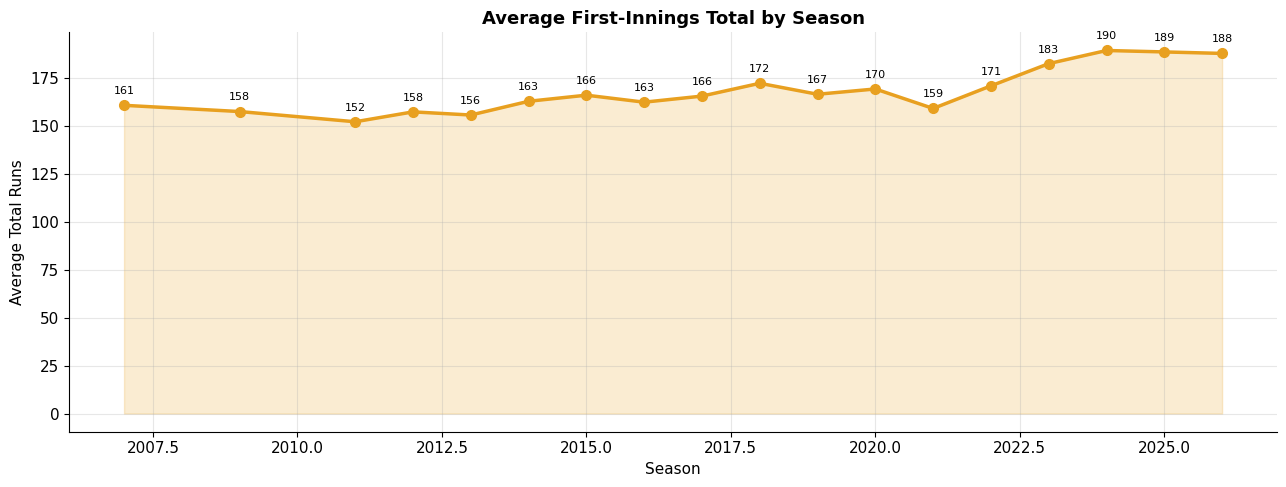

 INSIGHT: Average first-innings total has risen by ~27 runs from 2007 to 2026.


In [89]:
first_innings = phase_match[phase_match['innings'] == 1]
season_score  = first_innings.groupby(['match_id','season_year'])['runs'].sum().reset_index(name='total')
avg_score     = season_score.groupby('season_year')['total'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(avg_score.index, avg_score.values, alpha=0.2, color=C_GOLD)
ax.plot(avg_score.index, avg_score.values, color=C_GOLD, linewidth=2.5, marker='o', markersize=7)
for x_val, y_val in zip(avg_score.index, avg_score.values):
    ax.annotate(f'{y_val:.0f}', (x_val, y_val),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.set_title('Average First-Innings Total by Season', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Average Total Runs')
plt.tight_layout()
plt.show()

print(f' INSIGHT: Average first-innings total has risen by ~{avg_score.iloc[-1]-avg_score.iloc[0]:.0f} runs'
      f' from {avg_score.index[0]} to {avg_score.index[-1]}.')

### 8.2 Player of the Match Leaders

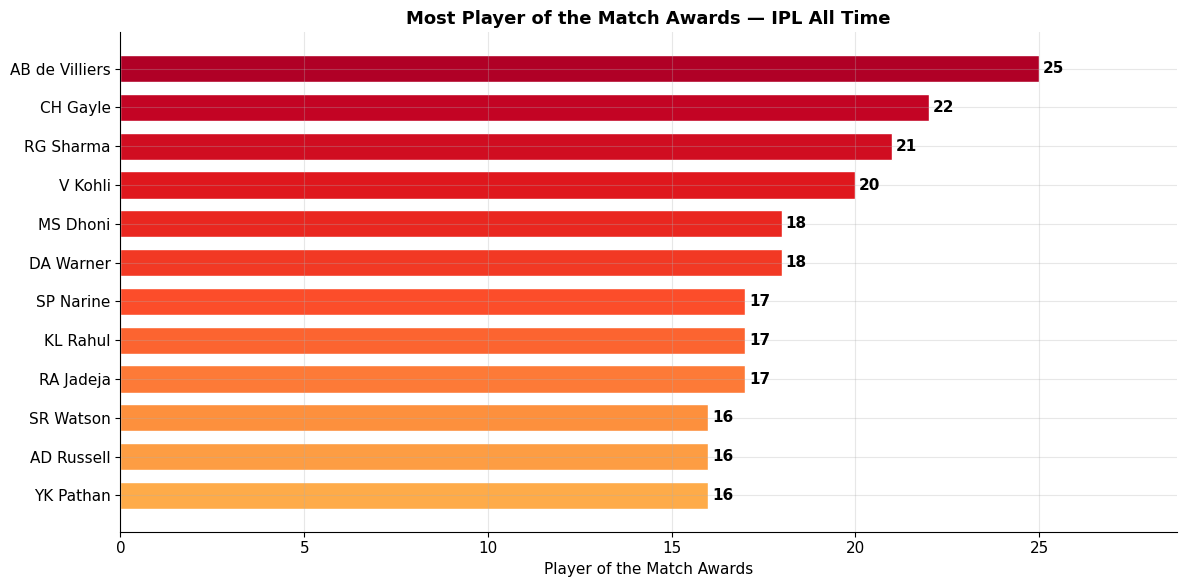

 Most impactful player: AB de Villiers with 25 POTM awards


In [90]:
pom = matches['player_of_match'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 6))
grad_colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(pom)))
bars = ax.barh(pom.index[::-1], pom.values[::-1], color=grad_colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, pom.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Player of the Match Awards')
ax.set_title('Most Player of the Match Awards — IPL All Time', fontsize=13, fontweight='bold')
ax.set_xlim(0, pom.max() * 1.15)
plt.tight_layout()
plt.show()

print(f' Most impactful player: {pom.index[0]} with {pom.iloc[0]} POTM awards')

### 8.3 Dismissal Types — How Do Wickets Fall?

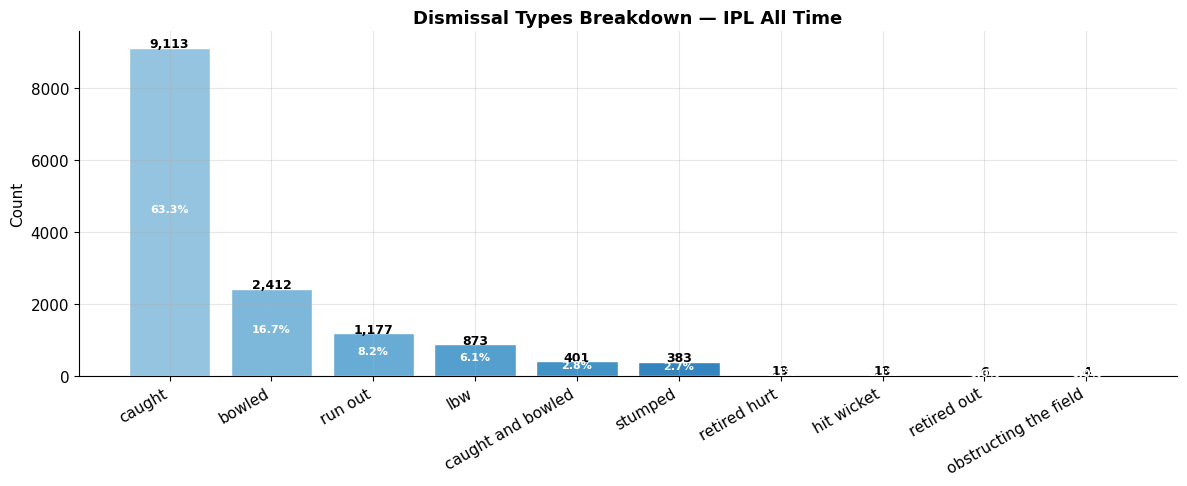

 "Caught" accounts for 63% of all dismissals — the dominant mode of dismissal in T20.


In [91]:
dismissals = deliveries['wicket_kind'].dropna().value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
dis_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(dismissals)))
bars = ax.bar(dismissals.index, dismissals.values, color=dis_colors, edgecolor='white')
for bar, val in zip(bars, dismissals.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
            f'{val/dismissals.sum()*100:.1f}%',
            ha='center', fontsize=8, color='white', fontweight='bold')
ax.set_xticklabels(dismissals.index, rotation=30, ha='right')
ax.set_ylabel('Count')
ax.set_title('Dismissal Types Breakdown — IPL All Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

caught_pct = dismissals.get('caught', 0) / dismissals.sum() * 100
print(f' "Caught" accounts for {caught_pct:.0f}% of all dismissals — the dominant mode of dismissal in T20.')

### 8.4 High-Risk High-Reward Batters (Aggressive Profile)

In [92]:
aggressive_batters = (
    batter_season.groupby('batter')
    .agg(strike_rate=('strike_rate','mean'), average=('average','mean'), runs=('runs','sum'))
    .reset_index()
)
aggressive_batters = aggressive_batters[aggressive_batters['runs'] >= 500]
aggressive_batters = aggressive_batters.nlargest(15, 'strike_rate')

print('Top 15 Aggressive Batters (High SR, min 500 runs):')
print(aggressive_batters[['batter','strike_rate','average','runs']]
      .to_string(index=False))

Top 15 Aggressive Batters (High SR, min 500 runs):
         batter  strike_rate   average  runs
  V Suryavanshi   222.102218 38.200000   656
  Priyansh Arya   212.323564 31.027778   831
        PD Salt   172.558502 32.687500  1258
   RD Rickelton   170.963768 42.065934   768
     Naman Dhir   170.137374 28.944444   648
       WG Jacks   164.969534 30.044444   520
 Shashank Singh   163.678009 35.622024   847
        TM Head   160.674740 33.367483  1507
Abhishek Sharma   159.247110 28.778956  2291
     RM Patidar   157.791704 32.835714  1368
       TH David   157.255455 36.222222  1038
       N Pooran   155.823540 32.370083  2438
    Dhruv Jurel   154.601210 30.603175   970
     AD Russell   153.582911 26.051984  2655
      MK Lomror   153.401018 18.482086   527


### 8.5 Bowler Control Matrix — Dot Ball % vs Economy

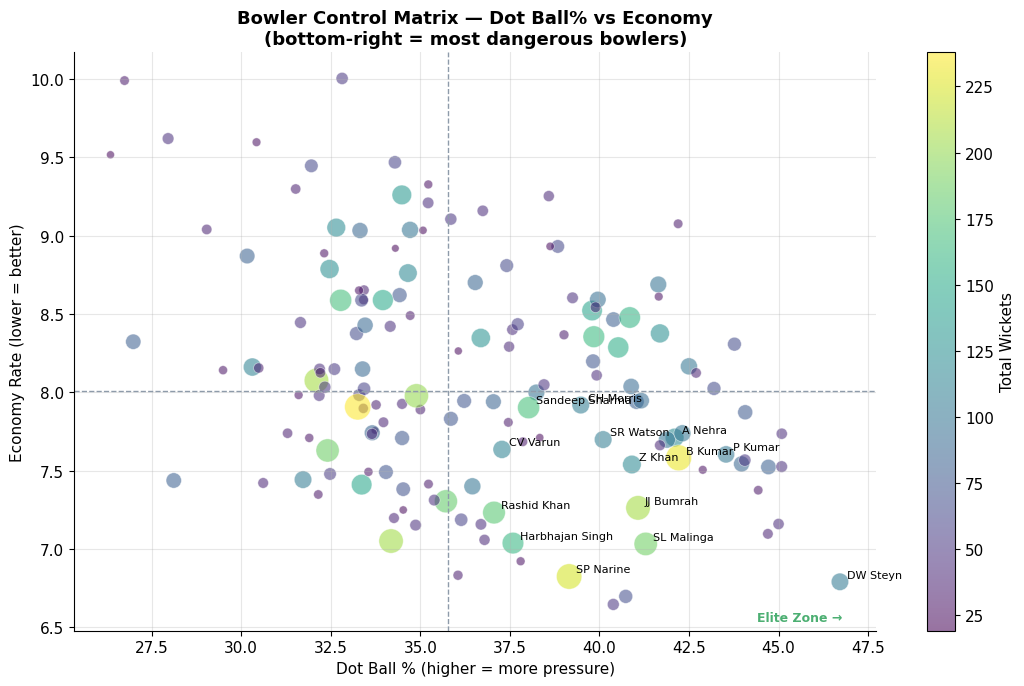

In [93]:
bowler_control = qualified_bowlers[['bowler','dot_pct','economy','wickets']].copy()
median_dot  = bowler_control['dot_pct'].median()
median_econ = bowler_control['economy'].median()

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(bowler_control['dot_pct'], bowler_control['economy'],
                s=bowler_control['wickets'] * 1.5, alpha=0.55,
                c=bowler_control['wickets'], cmap='viridis',
                edgecolors='white', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Total Wickets')
ax.axvline(median_dot,  color=C_GRAY, linestyle='--', linewidth=1)
ax.axhline(median_econ, color=C_GRAY, linestyle='--', linewidth=1)

# Label elite (high dot%, low economy)
elite_bowl = bowler_control[
    (bowler_control['dot_pct'] > median_dot) &
    (bowler_control['economy'] < median_econ) &
    (bowler_control['wickets'] > 100)
]
for _, row in elite_bowl.iterrows():
    ax.annotate(row['bowler'], (row['dot_pct'], row['economy']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xlabel('Dot Ball % (higher = more pressure)')
ax.set_ylabel('Economy Rate (lower = better)')
ax.set_title('Bowler Control Matrix — Dot Ball% vs Economy\n(bottom-right = most dangerous bowlers)',
             fontsize=13, fontweight='bold')
ax.text(ax.get_xlim()[1]*0.98, ax.get_ylim()[0]*1.01,
        'Elite Zone →', ha='right', color=C_GREEN, fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.6 Correlation Analysis — Phase Statistics

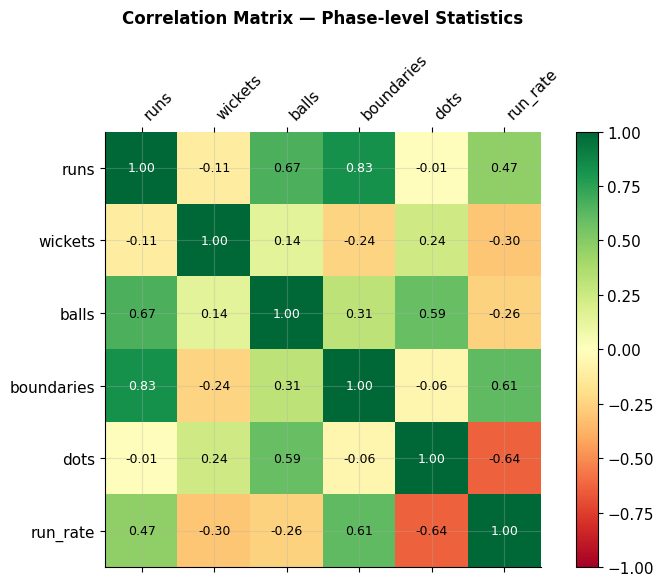

 Key correlations:
   Runs ↔ Boundaries: strong positive — boundaries drive scoring, as expected
   Runs ↔ Dots: negative — more dots = fewer runs (obvious but confirms data quality)
   Run Rate ↔ Boundaries: strongly positive — boundary hitting is the engine of the run rate


In [94]:
numeric_cols = phase_match[['runs', 'wickets', 'balls', 'boundaries', 'dots', 'run_rate']]
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(cax)
cols = corr.columns.tolist()
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha='left')
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='black' if abs(corr.iloc[i,j]) < 0.7 else 'white')
ax.set_title('Correlation Matrix — Phase-level Statistics', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(' Key correlations:')
print('   Runs ↔ Boundaries: strong positive — boundaries drive scoring, as expected')
print('   Runs ↔ Dots: negative — more dots = fewer runs (obvious but confirms data quality)')
print('   Run Rate ↔ Boundaries: strongly positive — boundary hitting is the engine of the run rate')

---

## 9. Team Performance Analysis

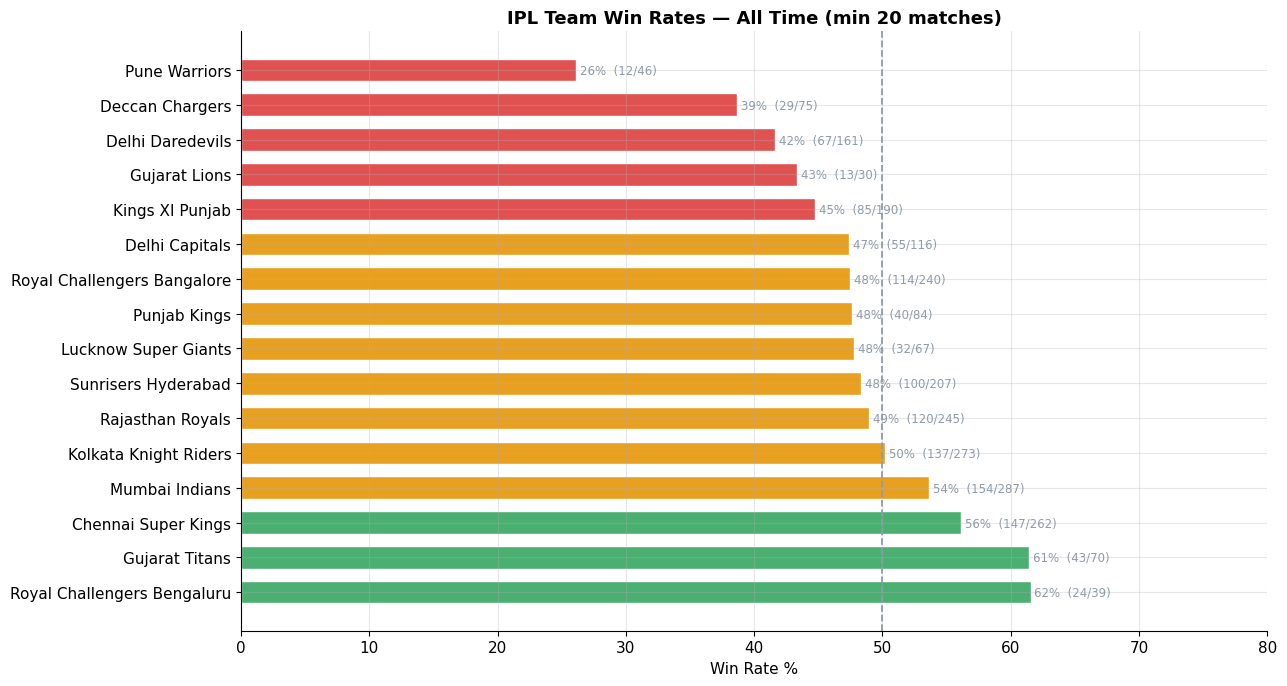

In [95]:
team_totals = (
    team_season.groupby('team')
    .agg(matches_played=('matches_played','sum'),
         wins=('wins','sum'),
         toss_wins=('toss_wins','sum'))
    .reset_index()
)
team_totals['win_rate']       = team_totals['wins'] / team_totals['matches_played'] * 100
team_totals['toss_win_rate']  = team_totals['toss_wins'] / team_totals['matches_played'] * 100
team_totals = team_totals[team_totals['matches_played'] >= 20].sort_values('win_rate', ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
bar_colors = [C_GREEN if w >= 55 else C_GOLD if w >= 45 else C_RED for w in team_totals['win_rate']]
bars = ax.barh(team_totals['team'], team_totals['win_rate'],
               color=bar_colors, edgecolor='white', height=0.65)
ax.axvline(50, color=C_GRAY, linestyle='--', linewidth=1.3)
for bar, row in zip(bars, team_totals.itertuples()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{row.win_rate:.0f}%  ({int(row.wins)}/{int(row.matches_played)})',
            va='center', fontsize=8.5, color=C_GRAY)
ax.set_xlabel('Win Rate %')
ax.set_title('IPL Team Win Rates — All Time (min 20 matches)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()

---

## 10. Final Summary

## 1. Toss Impact

- Winning the toss gives only a small advantage overall.
- Teams batting first win only around 44% of matches.
- Teams chasing have a better success rate at around 54%.
- The impact of the toss changes depending on the venue.

---

## 2. Match Phase Impact

- Death overs have the biggest impact on match results.
- The gap in scoring between winners and losers is highest in death overs.
- Middle overs create the most pressure because of high dot-ball percentages.
- Death-over scoring has increased significantly over the years.

---

## 3. Top Performers

### Batting
- V Kohli is the highest run scorer in IPL history.
- He has scored more than 9,000 runs with strong consistency.

### Bowling
- YS Chahal has taken the most wickets.
- SP Narine has been one of the most economical bowlers.

### Awards
- AB de Villiers has won the most Player of the Match awards.

---

## 4. Hidden Insights

- Around 60% of IPL runs come from boundaries.
- Chasing teams win more matches than teams batting first.
- Death overs influence the result much more than powerplays.